In [1]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords')
nltk.download('punkt')

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re

import matplotlib.pyplot as plt

import string
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Embedding, LSTM, Dense, Dropout, GRU , SimpleRNN

import tensorflow as tf

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [2]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [3]:
df = pd.read_csv("combined_data.csv")

In [4]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get your medircations online qnb ikud v...
2,0,computer connection from cnn com wednesday es...
3,1,university degree obtain a prosperous future m...
4,0,thanks for all your answers guys i know i shou...


In [5]:
df.isnull().sum()

,0
label,0
text,0


In [6]:
df.shape

(83448, 2)

In [7]:
df['text'] = df['text'].str.lower()

In [8]:
def remove_special(text):
  return text.translate(str.maketrans('','',string.punctuation))
df['text'] = df['text'].apply(remove_special)

In [9]:
stops = set(stopwords.words('english'))

In [10]:
def remove_stopwords(text):
  return [word for word in text if word not in stops]
df['text'] = df['text'].apply(word_tokenize)
df['text']=df['text'].apply(remove_stopwords)

In [11]:
df['text']=df['text'].apply(lambda x: " ".join(x))

In [12]:
df.head()

,label,text
0,1,ounce feather bowl hummingbird opec moment ala...
1,1,wulvob get medircations online qnb ikud viagra...
2,0,computer connection cnn com wednesday escapenu...
3,1,university degree obtain prosperous future mon...
4,0,thanks answers guys know checked rsync manual ...


In [13]:
def remove_hyperlink(word):
    return re.sub(r"http\S+", "", word)

df['text'] = df['text'].apply(remove_hyperlink)

In [14]:
import pandas as pd
import re
from collections import Counter

# 1. Filter only spam emails
spam_df = df[df['label'] == 1]   # change to == 1 if spam is labeled as 1

# 2. Combine all spam text into one string
all_spam_text = " ".join(spam_df['text'])

# 3. Clean text (lowercase, remove special characters & numbers)
all_spam_text = all_spam_text.lower()
all_spam_text = re.sub(r'[^a-z\s]', '', all_spam_text)

# 4. Split into words
words = all_spam_text.split()

# 5. Count word frequencies
word_freq = Counter(words)

# 6. Get Top 10 most common words
top_10_words = word_freq.most_common(10)

print("Top 10 most frequent words in SPAM emails:")
for word, freq in top_10_words:
    print(f"{word} : {freq}")


Top 10 most frequent words in SPAM emails:
escapenumber : 337411
escapelong : 188118
com : 29009
http : 27775
per : 26143
x : 23863
pills : 23128
escapenumbermg : 20541
price : 18724
company : 15873


In [15]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [16]:
max_features = 7000
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [17]:
average_length = sum(map(len, X_train_seq)) / len(X_train_seq)

In [18]:
max_length = 500
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length,padding = 'post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length,padding = 'post')

In [19]:
max_features = 7000
max_length = 500
embedding_length = 32

In [20]:
model_rnn = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_rnn.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
model_lstm = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    LSTM(64, use_cudnn=False),
    Dense(1, activation='sigmoid')
])
model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [22]:
model_gru = Sequential([
    Embedding(
        input_dim=max_features,
        output_dim=embedding_length,
        input_length=max_length,
        mask_zero=True
    ),
    GRU(64,use_cudnn=False),

    Dense(1, activation='sigmoid')
])
model_gru.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)
model_gru.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [23]:
EPOCHS = 10
BATCH_SIZE = 64

In [24]:
history_rnn = model_rnn.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 43ms/step - accuracy: 0.9537 - loss: 0.1365 - val_accuracy: 0.9806 - val_loss: 0.0581
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9814 - loss: 0.0603 - val_accuracy: 0.9822 - val_loss: 0.0559
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9571 - loss: 0.1293 - val_accuracy: 0.9674 - val_loss: 0.0962
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9346 - loss: 0.1661 - val_accuracy: 0.9772 - val_loss: 0.0766
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9765 - loss: 0.0744 - val_accuracy: 0.9746 - val_loss: 0.0863
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 41ms/step - accuracy: 0.9857 - loss: 0.0464 - val_accuracy: 0.9124 - val_loss: 0.2099
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 36s 41ms/step - accuracy: 0.9783 - loss: 0.0615 - val_accuracy: 0.9771 - val_loss: 0.0767
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accuracy: 0.9913 - loss: 0.0295 - 

In [25]:
import numpy as np

y_pred_prob = model_rnn.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step


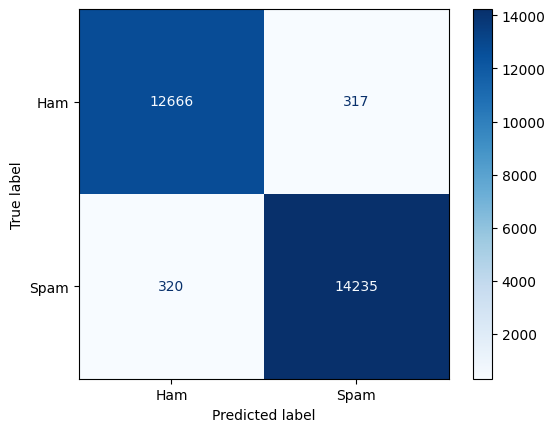

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)
disp.plot(cmap='Blues')
plt.show()


In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     12983
           1       0.98      0.98      0.98     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



In [28]:
history_lstm = model_lstm.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 48s 50ms/step - accuracy: 0.9635 - loss: 0.1144 - val_accuracy: 0.9826 - val_loss: 0.0561
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9834 - loss: 0.0554 - val_accuracy: 0.9824 - val_loss: 0.0560
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9884 - loss: 0.0384 - val_accuracy: 0.9843 - val_loss: 0.0486
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9935 - loss: 0.0230 - val_accuracy: 0.9839 - val_loss: 0.0498
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9946 - loss: 0.0184 - val_accuracy: 0.9844 - val_loss: 0.0598
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 46ms/step - accuracy: 0.9933 - loss: 0.0237 - val_accuracy: 0.9845 - val_loss: 0.0578
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9969 - loss: 0.0106 - val_accuracy: 0.9834 - val_loss: 0.0619
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9974 - loss: 0.0097 - 

In [29]:
history_gru = model_gru.fit(
    X_train_pad,
    y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_pad, y_test),
    verbose=1
)

Epoch 1/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 54s 58ms/step - accuracy: 0.9617 - loss: 0.1059 - val_accuracy: 0.9815 - val_loss: 0.0611
Epoch 2/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9851 - loss: 0.0492 - val_accuracy: 0.9836 - val_loss: 0.0577
Epoch 3/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 82s 54ms/step - accuracy: 0.9907 - loss: 0.0322 - val_accuracy: 0.9856 - val_loss: 0.0443
Epoch 4/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9939 - loss: 0.0223 - val_accuracy: 0.9855 - val_loss: 0.0470
Epoch 5/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9951 - loss: 0.0189 - val_accuracy: 0.9859 - val_loss: 0.0464
Epoch 6/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9957 - loss: 0.0152 - val_accuracy: 0.9871 - val_loss: 0.0456
Epoch 7/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9972 - loss: 0.0102 - val_accuracy: 0.9863 - val_loss: 0.0516
Epoch 8/10
874/874 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - accuracy: 0.9980 - loss: 0.0075 - 

In [30]:
import numpy as np

y_pred_prob_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = (y_pred_prob_lstm > 0.5).astype(int)


861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step


In [31]:
from sklearn.metrics import accuracy_score

lstm_accuracy = accuracy_score(y_test, y_pred_lstm)
print("LSTM Accuracy:", lstm_accuracy)

LSTM Accuracy: 0.9847846611954391


In [32]:
from sklearn.metrics import classification_report

print("LSTM Classification Report:")
print(classification_report(y_test, y_pred_lstm, target_names=["Ham", "Spam"]))

LSTM Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.98     12983
        Spam       0.98      0.99      0.99     14555

    accuracy                           0.98     27538
   macro avg       0.98      0.98      0.98     27538
weighted avg       0.98      0.98      0.98     27538



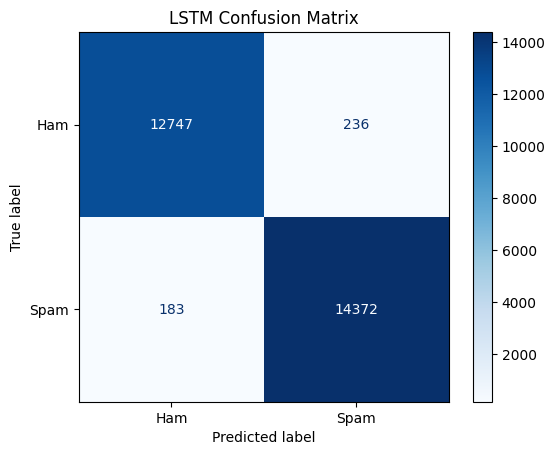

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_lstm = confusion_matrix(y_test, y_pred_lstm)

ConfusionMatrixDisplay(
    confusion_matrix=cm_lstm,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("LSTM Confusion Matrix")
plt.show()


In [34]:
y_pred_prob_gru = model_gru.predict(X_test_pad)
y_pred_gru = (y_pred_prob_gru > 0.5).astype(int)

861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


In [35]:
gru_accuracy = accuracy_score(y_test, y_pred_gru)
print("GRU Accuracy:", gru_accuracy)


GRU Accuracy: 0.9864913937105091


In [36]:
print("GRU Classification Report:")
print(classification_report(y_test, y_pred_gru, target_names=["Ham", "Spam"]))


GRU Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99     12983
        Spam       0.99      0.99      0.99     14555

    accuracy                           0.99     27538
   macro avg       0.99      0.99      0.99     27538
weighted avg       0.99      0.99      0.99     27538



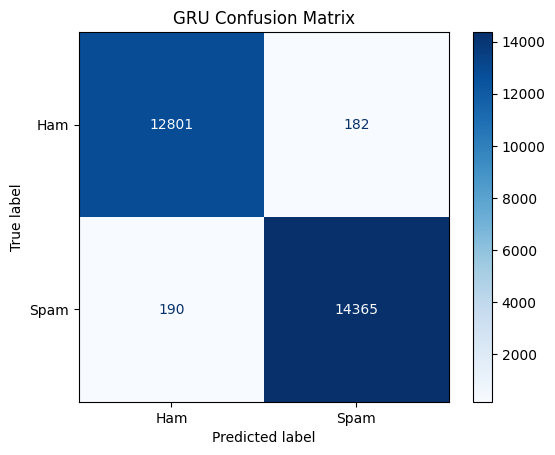

In [37]:
cm_gru = confusion_matrix(y_test, y_pred_gru)

ConfusionMatrixDisplay(
    confusion_matrix=cm_gru,
    display_labels=["Ham", "Spam"]
).plot(cmap="Blues")

plt.title("GRU Confusion Matrix")
plt.show()

In [38]:
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

def evaluate_model(model, X_test, y_test, model_name):
    y_prob = model.predict(X_test)
    y_pred = (y_prob > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )

    return {
        "Model": model_name,
        "Accuracy": acc,
        "Spam Precision": report["1"]["precision"],
        "Spam Recall": report["1"]["recall"],
        "Spam F1": report["1"]["f1-score"]
    }


In [39]:
results = []

results.append(evaluate_model(model_rnn, X_test_pad, y_test, "Simple RNN"))
results.append(evaluate_model(model_lstm, X_test_pad, y_test, "LSTM"))
results.append(evaluate_model(model_gru, X_test_pad, y_test, "GRU"))

results_df = pd.DataFrame(results)
print(results_df)


861/861 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
861/861 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
        Model  Accuracy  Spam Precision  Spam Recall   Spam F1
0  Simple RNN  0.976868        0.978216     0.978014  0.978115
1        LSTM  0.984785        0.983844     0.987427  0.985632
2         GRU  0.986491        0.987489     0.986946  0.987217


In [40]:
best_model_row = results_df.sort_values(
    by="Spam F1",
    ascending=False
).iloc[0]

print("Best Model:")
print(best_model_row)


Best Model:
Model                  GRU
Accuracy          0.986491
Spam Precision    0.987489
Spam Recall       0.986946
Spam F1           0.987217
Name: 2, dtype: object


In [41]:
model_gru.save("gru_model.keras")

In [42]:
import pickle

with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

In [43]:
config = {
    "max_features": max_features,
    "max_length": max_length,
    "embedding_length": embedding_length
}

with open("config.pkl", "wb") as f:
    pickle.dump(config, f)

In [44]:
label_mapping = {0: "Ham", 1: "Spam"}

with open("label_mapping.pkl", "wb") as f:
    pickle.dump(label_mapping, f)